In [42]:
import torch
from torch import nn  # Neural network module
import matplotlib.pyplot as plt  # For plotting

In [43]:
#  Generate Input Data (X) and Output Data (y)
torch.manual_seed(71)  # For reproducibility
#Include your code here

input_data = torch.linspace(1, 50, 50).reshape(-1, 1)
noise = torch.randint( low=-8, high=9, size=(50, 1), dtype=torch.float )
target_data = 2 * input_data + 1 + noise


In [44]:
print("Input Data : \n",input_data)
print("\nTarget Data : \n",target_data)

Input Data : 
 tensor([[ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.],
        [40.],
        [41.],
        [42.],
        [43.],
        [44.],
        [45.],
        [46.],
        [47.],
        [48.],
        [49.],
        [50.]])

Target Data : 
 tensor([[ 5.],
        [12.],
        [ 9.],
        [15.],
        [13.],
        [ 9.],
        [17.],
        [12.],
        [23.],
        [22.],
        [25.],
        [28.],
        [28.],
        [21.],
       

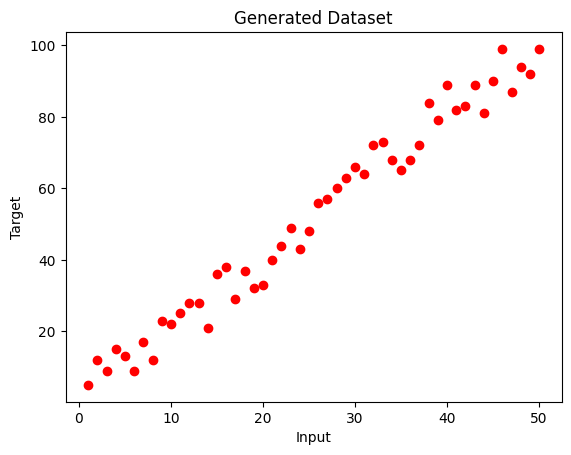

In [45]:
# Plot the original data
plt.scatter( input_data, target_data, color="red" )
plt.xlabel("Input")
plt.ylabel("Target")
plt.title("Generated Dataset")
plt.show()

In [46]:
# Define the Linear Model Class
class Model(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        #Include your code here

        self.linear_layer = nn.Linear(in_features=in_features, out_features=out_features)

    def forward(self, input_tensor):
        #Include your code here
        return self.linear_layer(input_tensor)


In [47]:
# Initialize the Model
torch.manual_seed(59)  # Ensure same initial weights
model = Model(1, 1)

In [48]:
# Print Initial Weights and Bias
initial_weight = (model.linear_layer.weight.item())
initial_bias = (model.linear_layer.bias.item())
print("\nName: Arunsamy D")
print("Register No: 212224240016")
print(f'Initial Weight: {initial_weight:.8f}, Initial Bias: {initial_bias:.8f}\n')


Name: Arunsamy D
Register No: 212224240016
Initial Weight: 0.10597813, Initial Bias: 0.96379614



In [49]:
# Define Loss Function & Optimizer
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

In [50]:
# Train the Model
epochs = 100
losses = []

for epoch in range(1, epochs + 1):  # Loop over epochs
    #Include your code here

    predicted_output = model(input_data)

    loss = loss_function(predicted_output, target_data)

    losses.append(loss.item())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # Print loss, weight, and bias for EVERY epoch
    print(f'epoch: {epoch:2}  loss: {loss.item():10.8f}  '
          f'weight: {model.linear_layer.weight.item():10.8f}  '
          f'bias: {model.linear_layer.bias.item():10.8f}')

epoch:  1  loss: 3057.21679688  weight: 3.33490014  bias: 1.06046367
epoch:  2  loss: 1588.53063965  weight: 1.01483285  bias: 0.99226284
epoch:  3  loss: 830.29992676  weight: 2.68179941  bias: 1.04252183
epoch:  4  loss: 438.85217285  weight: 1.48402131  bias: 1.00766504
epoch:  5  loss: 236.76144409  weight: 2.34460592  bias: 1.03396463
epoch:  6  loss: 132.42912292  weight: 1.72622538  bias: 1.01632178
epoch:  7  loss: 78.56572723  weight: 2.17050409  bias: 1.03025162
epoch:  8  loss: 50.75775909  weight: 1.85124576  bias: 1.02149546
epoch:  9  loss: 36.40123367  weight: 2.08060074  bias: 1.02903891
epoch: 10  loss: 28.98922920  weight: 1.91576838  bias: 1.02487016
epoch: 11  loss: 25.16238213  weight: 2.03416562  bias: 1.02911627
epoch: 12  loss: 23.18647385  weight: 1.94905841  bias: 1.02731562
epoch: 13  loss: 22.16612625  weight: 2.01017213  bias: 1.02985907
epoch: 14  loss: 21.63911057  weight: 1.96622372  bias: 1.02928054
epoch: 15  loss: 21.36677170  weight: 1.99776423  bias

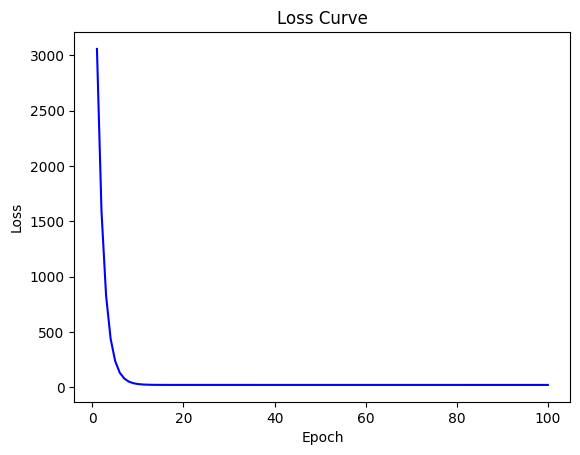

In [51]:
# Plot Loss Curve
plt.plot(range(1, epochs+1), losses, color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Loss Curve')
plt.show()

In [52]:
# Final Weights & Bias
final_weight = model.linear_layer.weight.item()
final_bias = model.linear_layer.bias.item()
print("\nName: Arunsamy D")
print("Register No: 212224240016")
print(f'\nFinal Weight: {final_weight:.8f}, Final Bias: {final_bias:.8f}')


Name: Arunsamy D
Register No: 212224240016

Final Weight: 1.98277164, Final Bias: 1.09101629


In [53]:
#  Best-Fit Line Calculation
line_x = torch.tensor([
    input_data.min().item(),
    input_data.max().item()
]) # Find min and max values of X

line_y = ( line_x * final_weight + final_bias ) # Compute corresponding y-values using trained model

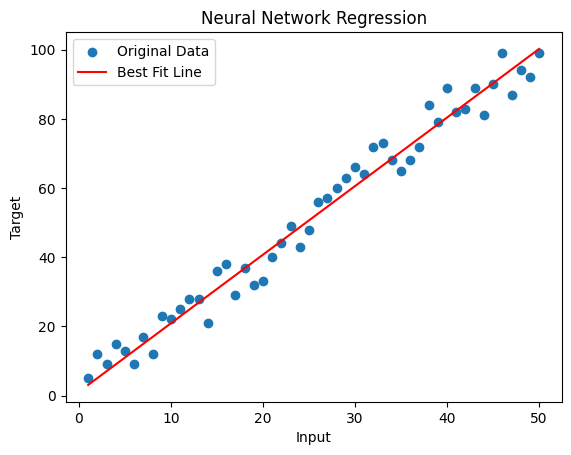

In [54]:
# Plot Original Data & Best-Fit Line
plt.scatter( input_data, target_data, label="Original Data" )
plt.plot( line_x, line_y, "r", label="Best Fit Line" )
plt.xlabel("Input")
plt.ylabel("Target")
plt.title( "Neural Network Regression" )
plt.legend()
plt.show()

In [55]:
# Prediction for x = 120
x_new = torch.tensor([[120.0]])  # New input as a tensor
y_new_pred = model(x_new).item()  # Predict using trained model

new_input = torch.tensor([ [120.0] ])
predicted_value = model( new_input ).item()
print("\nName : Arunsamy D")
print("Register No : 212224240016")
print( f"\nPrediction for x = 120 : " f"{predicted_value:.8f}" )


Name : Arunsamy D
Register No : 212224240016

Prediction for x = 120 : 239.02362061


In [56]:
# New Sample Data Prediction

# Input Value (x) : 120

# Predicted Output (y) : 241.356781

new_input = torch.tensor([[120.0]])

predicted_value = model(new_input).item()

print(f"Prediction for x = 120 : {predicted_value:.8f}")

Prediction for x = 120 : 239.02362061
